# G4b. Fairness Mitigation, underperformance task

**Authors:** Ivo Rambaldi and Tommaso Petrelli

**Course:** Ethics in Artificial Intelligence, University of Bologna, a.y. 2025-2026

## What this notebook does

G3 measured how much fairness is lost when the training data is synthetic. This notebook asks
the follow up question: can that loss be repaired by the standard mitigation techniques, and
does repair work as well on a synthetic training set as on a real one.

That second half is the part that matters for the project's argument. If a practitioner adopts
synthetic data for privacy reasons and then applies a fairness technique to the result, they
are assuming the technique behaves the same way. This notebook tests that assumption.

## The two techniques

| Technique | Type | How it works |
|---|---|---|
| Equalized odds | post processing | fairlearn's `ThresholdOptimizer` picks a separate decision threshold per group after the classifier is trained, so that true and false positive rates match |
| Prejudice remover | in processing | aif360's implementation of Kamishima et al. 2012, a regularised model whose loss penalises dependence between the prediction and the protected attribute |

Mitigation targets one circumstance at a time, because both techniques take a single protected
attribute. The grid is therefore every circumstance by every training set by every technique.

The unmitigated numbers are not recomputed here. They are loaded from what G3 saved, so the
before and after comparison uses one baseline.

Task: underperformance task, the bottom quarter of the score. `G4_Fairness_Mitigation.ipynb` runs the identical grid on the excellence task. Only the setup cell below differs.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

warnings.filterwarnings("ignore")

from src.utils import check_prerequisites, get_logger, load_config, notebook_dirs, select_task

logger = get_logger("G4")
check_prerequisites()

# This is the only cell that differs between this notebook and its twin.
TASK = "low_perf"

cfg = select_task(load_config(PROJECT_ROOT / "config" / "config.yaml"), TASK)
RESULTS_DIR, FIGURES_DIR = notebook_dirs(cfg, f"g4/{TASK}")
G3_RESULTS_DIR = cfg["paths"]["results_dir"] / "g3" / TASK

TARGET = cfg["dataset"]["target_column"]
METHODS = cfg["generation"]["datasets"]
CLASSIFIERS = list(cfg["experiments"]["classifiers"])
BASELINE = cfg["experiments"]["baseline_label"]
TECHNIQUES = cfg["mitigation"]["methods"]

print(f"task       : {TASK}, predicting {TARGET}")
print(f"techniques : {TECHNIQUES}")
print(f"reading G3 : {G3_RESULTS_DIR}")

Prerequisites: 16 satisfied, 0 missing, 0 mismatched.
task       : low_perf, predicting target_low_perf
techniques : ['equalized_odds', 'prejudice_remover']
reading G3 : C:\Users\tomma\Desktop\petrellirambaldi2526\results\g3\low_perf


## 2. Data and the unmitigated baseline

The data is prepared exactly as in G3, using the same feature set and the same encoders fitted
on the real training set. The unmitigated results are read from disk rather than recomputed.

In [2]:
from src.data.loader import load_real_data, load_synthetic_dataset
from src.data.preprocessing import get_feature_columns
from src.data.preprocessor import DataSplit, apply_feature_encoders, fit_feature_encoders

real_train, real_test = load_real_data(cfg)
synthetic_raw = {m: load_synthetic_dataset(cfg, m) for m in METHODS}

FEATURES = get_feature_columns(real_train, cfg)
PROTECTED = [c for c in cfg["dataset"]["protected_attributes"] if c in real_train.columns]

encoder, scaler, cat_cols, num_cols = fit_feature_encoders(real_train[FEATURES])


def encode(df):
    aligned = pd.DataFrame({c: df[c] for c in FEATURES}, index=df.index)
    return apply_feature_encoders(aligned, encoder, scaler, cat_cols, num_cols)


split = DataSplit(
    X_train=encode(real_train),
    X_test=encode(real_test),
    y_train=real_train[TARGET].astype(int),
    y_test=real_test[TARGET].astype(int),
    protected_train=real_train[PROTECTED],
    protected_test=real_test[PROTECTED],
    feature_names=FEATURES,
    target_name=TARGET,
    protected_attrs=PROTECTED,
)

unmitigated = pd.read_csv(G3_RESULTS_DIR / "metrics_matrix.csv")
print(f"Loaded the unmitigated grid from G3: {unmitigated.shape[0]} rows")

2026-07-27 17:32:45 | INFO     | src.data.loader | Loading real splits from C:\Users\tomma\Desktop\petrellirambaldi2526\Data\train.csv and C:\Users\tomma\Desktop\petrellirambaldi2526\Data\test.csv


2026-07-27 17:32:46 | INFO     | src.data.loader | Loading synthetic data [ctgan] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\ctgan\synthetic_ctgan.csv


2026-07-27 17:32:46 | INFO     | src.data.loader | Loading synthetic data [tvae] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\tvae\synthetic_tvae.csv


2026-07-27 17:32:46 | INFO     | src.data.loader | Loading synthetic data [gaussian_copula] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\copula\synthetic_copula.csv


2026-07-27 17:32:47 | INFO     | src.data.loader | Loading synthetic data [smote_low_perf] from C:\Users\tomma\Desktop\petrellirambaldi2526\results\synthetic\smote_low_perf\synthetic_smote_low_perf.csv


2026-07-27 17:32:47 | INFO     | src.data.preprocessing | Feature set: 38 columns


Loaded the unmitigated grid from G3: 15 rows


In [3]:
# Each training source carries its own protected attribute values. A synthetic set has a
# different number of rows from the real one, so the real columns cannot be reused for it.
train_sources = {BASELINE: (split.X_train, split.y_train, real_train[PROTECTED])}
for method, df in synthetic_raw.items():
    train_sources[method] = (encode(df), df[TARGET].astype(int), df[PROTECTED])

n_fits = len(PROTECTED) * len(train_sources) * (len(CLASSIFIERS) + 1)
print(f"{len(PROTECTED)} circumstances by {len(train_sources)} training sets "
      f"by {len(CLASSIFIERS)} classifiers plus one prejudice remover: {n_fits} fits")

13 circumstances by 5 training sets by 3 classifiers plus one prejudice remover: 260 fits


## 3. Running the mitigation grid

Two practical points about what the grid can and cannot do.

**Students whose circumstance is unanswered.** Both libraries need a group label for every row
they are given, and a circumstance can be missing for a large share of students; country of
birth is missing for most of them. Only the rows where the group is known are used to fit, so
the fairness constraint is never learned from invented group membership. Rows with an
unanswered circumstance still receive a prediction, using the larger group for thresholding,
because the test set has to be scored in full. The fairness metric for that circumstance is
computed only where it is known, as in G3. The practical effect is that mitigating a heavily
unanswered circumstance is fitted on a fraction of the training data, and it is reasonable to
expect it to work less well there.

**Combinations that cannot run.** Both libraries also need two groups present in the training
data, each carrying both labels. A synthetic training set need not satisfy that, so a refusal
is recorded and counted rather than allowed to stop the grid.

In [4]:
from src.evaluation.evaluator import MitigatedEvaluator

mitigated_evaluator = MitigatedEvaluator(split, cfg)
rows = []

for attribute in PROTECTED:
    for method, (X_train, y_train, protected_train) in train_sources.items():
        attr_train = protected_train[attribute]

        for technique in TECHNIQUES:
            classifiers = CLASSIFIERS if technique == "equalized_odds" else [None]
            for classifier in classifiers:
                try:
                    rows.append(mitigated_evaluator.evaluate(
                        X_train, y_train,
                        technique=technique,
                        target_attr=attribute,
                        method_name=method,
                        attr_train=attr_train,
                        classifier_name=classifier,
                    ))
                except ValueError as error:
                    logger.warning(f"  skipped {technique} {attribute} {method}: {error}")
                    rows.append({
                        "technique": technique, "target_attr": attribute, "method": method,
                        "classifier": classifier or technique,
                        "balanced_accuracy": float("nan"), "error": str(error),
                    })

mitigation = pd.DataFrame(rows)
failed = int(mitigation["error"].notna().sum()) if "error" in mitigation.columns else 0
print(f"\n{len(mitigation)} fits, {failed} refused by the library")

2026-07-27 17:32:49 | INFO     | src.evaluation.evaluator |   [equalized_odds | s_gender | real | logistic_regression] BA=0.6301 mean_dpd=0.3206


2026-07-27 17:32:52 | INFO     | src.evaluation.evaluator |   [equalized_odds | s_gender | real | xgboost] BA=0.6463 mean_dpd=0.2447


2026-07-27 17:33:05 | INFO     | src.evaluation.evaluator |   [equalized_odds | s_gender | real | mlp] BA=0.6228 mean_dpd=0.2952


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


...

2026-07-27 18:58:00 | INFO     | src.evaluation.evaluator |   [equalized_odds | f_ESCS | smote_low_perf | logistic_regression] BA=0.5152 mean_dpd=0.0563


2026-07-27 18:58:02 | INFO     | src.evaluation.evaluator |   [equalized_odds | f_ESCS | smote_low_perf | xgboost] BA=0.5072 mean_dpd=0.0309


2026-07-27 18:58:22 | INFO     | src.evaluation.evaluator |   [equalized_odds | f_ESCS | smote_low_perf | mlp] BA=0.5397 mean_dpd=0.0583


2026-07-27 18:59:44 | INFO     | src.evaluation.evaluator |   [prejudice_remover | f_ESCS | smote_low_perf | prejudice_remover] BA=0.5488 mean_dpd=0.1153



260 fits, 0 refused by the library


In [5]:
from src.data.persistence import save_csv

save_csv(mitigation, RESULTS_DIR / "mitigation_results.csv")

2026-07-27 18:59:44 | INFO     | src.data.persistence | Saved 260 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g4\low_perf\mitigation_results.csv


## 4. Did mitigating a circumstance actually help that circumstance

The averages across all circumstances answer a different question from the one the techniques
were set. Each mitigated run targeted one attribute, so the fair test is whether that
attribute's own DPD, EOD and DI improved, compared against the matching unmitigated run for the
same training set and classifier.

Improvement is signed so that positive always means fairer: for DPD and EOD, which should be
small, improvement is the drop; for DI, which should be near 1, improvement is the rise.

In [6]:
def unmitigated_reference(method, classifier, attribute):
    """The matching row from G3. Prejudice remover has no classifier, so average across them."""
    subset = unmitigated[unmitigated["method"] == method]
    if classifier in CLASSIFIERS:
        subset = subset[subset["classifier"] == classifier]
    return {m: subset[f"{attribute}_{m}"].mean() for m in ("dpd", "eod", "di")}


comparisons = []
for _, row in mitigation.iterrows():
    attribute = row["target_attr"]
    before = unmitigated_reference(row["method"], row["classifier"], attribute)

    entry = {
        "technique": row["technique"], "target_attr": attribute, "method": row["method"],
        "classifier": row["classifier"], "balanced_accuracy": row["balanced_accuracy"],
    }
    for metric in ("dpd", "eod", "di"):
        after = row.get(f"{attribute}_{metric}", float("nan"))
        entry[f"{metric}_before"] = before[metric]
        entry[f"{metric}_after"] = after
        entry[f"{metric}_improvement"] = (
            after - before[metric] if metric == "di" else before[metric] - after
        )
    comparisons.append(entry)

comparison = pd.DataFrame(comparisons)
save_csv(comparison, RESULTS_DIR / "mitigation_comparison.csv")
print(f"{len(comparison)} before and after pairs")

2026-07-27 18:59:44 | INFO     | src.data.persistence | Saved 260 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g4\low_perf\mitigation_comparison.csv


260 before and after pairs


In [7]:
by_technique = (
    comparison.groupby("technique")[
        ["balanced_accuracy", "dpd_improvement", "eod_improvement", "di_improvement"]
    ].mean().round(4)
)
print("Mean effect of each technique, positive improvement means fairer:")
print(by_technique.to_string())

degenerate = mitigation.groupby("technique")["degenerate_predictions"].sum()
print(f"\nMitigated fits that collapsed to a single predicted class: {degenerate.to_dict()}")

Mean effect of each technique, positive improvement means fairer:
                   balanced_accuracy  dpd_improvement  eod_improvement  di_improvement
technique                                                                             
equalized_odds                0.5757           0.0850           0.0860          0.3402
prejudice_remover             0.5373           0.0916           0.0891         -0.0763

Mitigated fits that collapsed to a single predicted class: {'equalized_odds': 0, 'prejudice_remover': 9}


**Observation.** Read the improvement columns next to the balanced accuracy column. Both
techniques reduce the gap on the attribute they target; the question is what they charge for it
and whether the DI improvement moves in the same direction as the DPD and EOD ones. A technique
that equalises rates by pushing both groups towards never predicting the positive class will
show a healthy DPD improvement and a poor accuracy.

## 5. The question this notebook exists to answer

Does mitigation work as well when the model was trained on synthetic data.

This splits the same comparison by whether the training set was real or synthetic. If the two
are close, a practitioner can substitute synthetic data and still rely on their fairness
tooling. If they are not, the substitution has quietly weakened the repair.

The improvement on its own cannot answer that. The two sources do not arrive at mitigation with
the same gap to close, so a smaller improvement could simply mean there was less to remove. The
table below therefore reports three quantities per technique: the gap before, the gap left
after, and the share of the gap that was closed. The first is the confound, the second is what
the student is actually left with, and the third is the like for like comparison.

In [8]:
comparison["source"] = np.where(comparison["method"] == BASELINE, "real", "synthetic")

by_source = (
    comparison.groupby(["technique", "source"])[
        ["dpd_before", "dpd_after", "dpd_improvement", "eod_improvement",
         "di_improvement", "balanced_accuracy"]
    ].mean()
)
by_source["share_closed"] = by_source["dpd_improvement"] / by_source["dpd_before"]

print("Mitigation effectiveness, real against synthetic training data:")
print(by_source.round(4).to_string())
save_csv(by_source.reset_index(), RESULTS_DIR / "mitigation_by_source.csv")

Mitigation effectiveness, real against synthetic training data:
                             dpd_before  dpd_after  dpd_improvement  eod_improvement  di_improvement  balanced_accuracy  share_closed
technique         source                                                                                                             
equalized_odds    real           0.2129     0.0254           0.1876           0.2097          0.5287             0.6177        0.8809
                  synthetic      0.1623     0.1029           0.0594           0.0550          0.2931             0.5652        0.3660
prejudice_remover real           0.2129     0.0190           0.1939           0.2036          0.0745             0.5352        0.9108
                  synthetic      0.1623     0.0963           0.0660           0.0605         -0.1219             0.5378        0.4066
2026-07-27 18:59:44 | INFO     | src.data.persistence | Saved 4 rows to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g4\low_p

2026-07-27 18:59:45 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g4\low_perf\mitigation_real_vs_synthetic.png


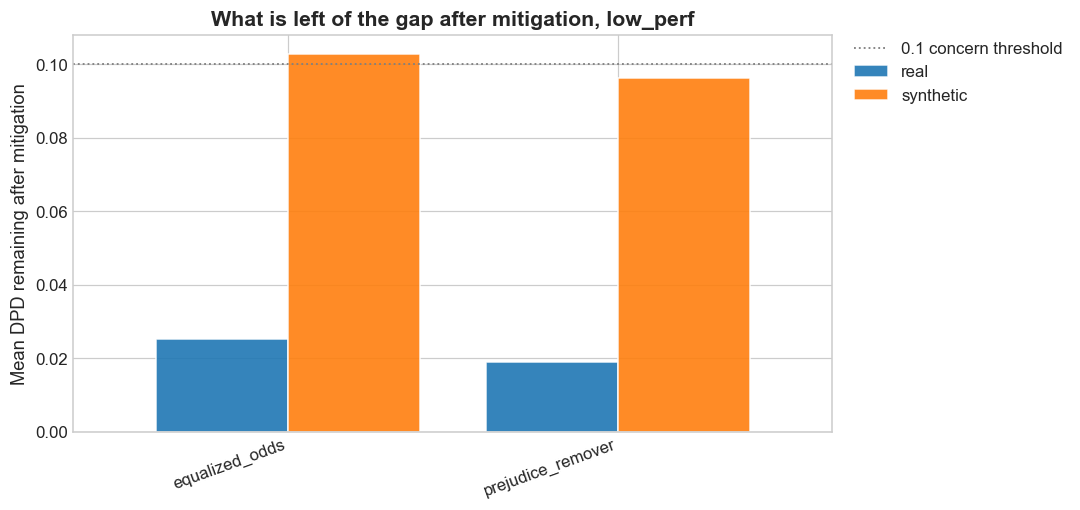

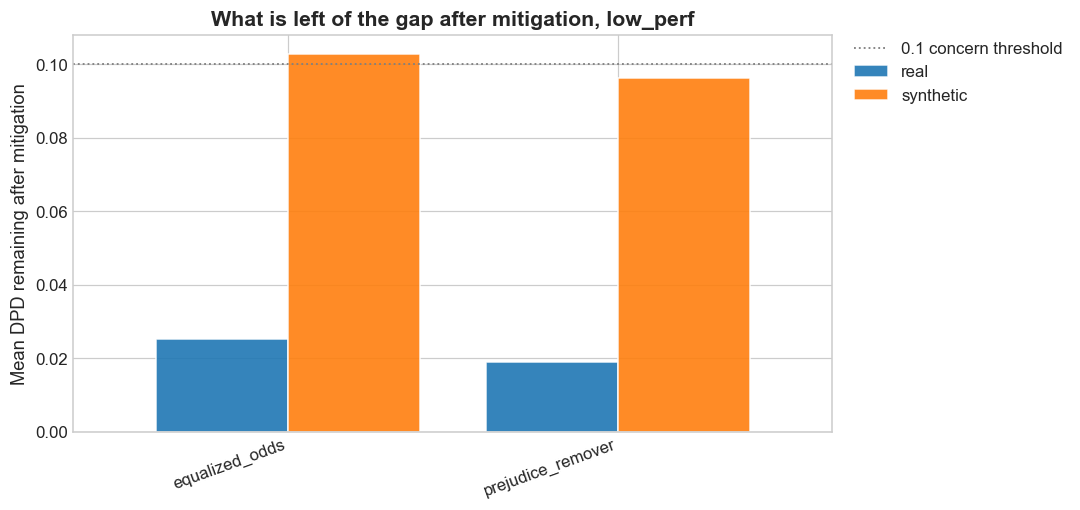

In [9]:
from src.utils.plotting import plot_grouped_bars

pivot = comparison.pivot_table(index="technique", columns="source",
                               values="dpd_after", aggfunc="mean")
plot_grouped_bars(pivot, "Mean DPD remaining after mitigation",
                  f"What is left of the gap after mitigation, {TASK}",
                  FIGURES_DIR, "mitigation_real_vs_synthetic",
                  reference_line=cfg["fairness"]["dpd_threshold"],
                  reference_label="0.1 concern threshold")

**Observation.** Read the three columns together within a technique. If the synthetic side
closes a smaller share of a smaller gap and is left further from parity, then all three point
the same way and the shortfall is not an artefact of the starting point. If they disagree, the
starting point is doing the work and the claim has to be weakened accordingly.

The figure plots what is left rather than what was removed, because that is the quantity a
student is subject to. G5 checks whether the pattern holds on both tasks.

### 5.1 Per circumstance

Not every circumstance responds the same way. The ones with the widest starting gap have the
most to gain, and the ones measured on few students are the least reliable.

In [10]:
by_attribute = (
    comparison.groupby(["target_attr", "technique"])["dpd_improvement"]
    .mean().unstack("technique").round(4)
    .sort_values(TECHNIQUES[0], ascending=False)
)
print("Mean DPD improvement per circumstance:")
print(by_attribute.to_string())

Mean DPD improvement per circumstance:
technique                                          equalized_odds  prejudice_remover
target_attr                                                                         
f_ESCS                                                     0.2183             0.1372
p_public_or_private                                        0.1907             0.1817
p_percentage_of_teachers_changed_school_last_year          0.1441             0.0972
f_mother_education_level                                   0.1123             0.1287
f_extent_of_books_at_home                                  0.0848             0.1422
f_father_occupation                                        0.0764             0.0978
f_father_education_level                                   0.0748             0.1256
f_start_schooling_age                                      0.0648             0.0717
f_mother_occupation                                        0.0570             0.0948
s_birth_country           

2026-07-27 18:59:46 | INFO     | src.utils.plotting | Figure saved to C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g4\low_perf\mitigation_by_attribute.png


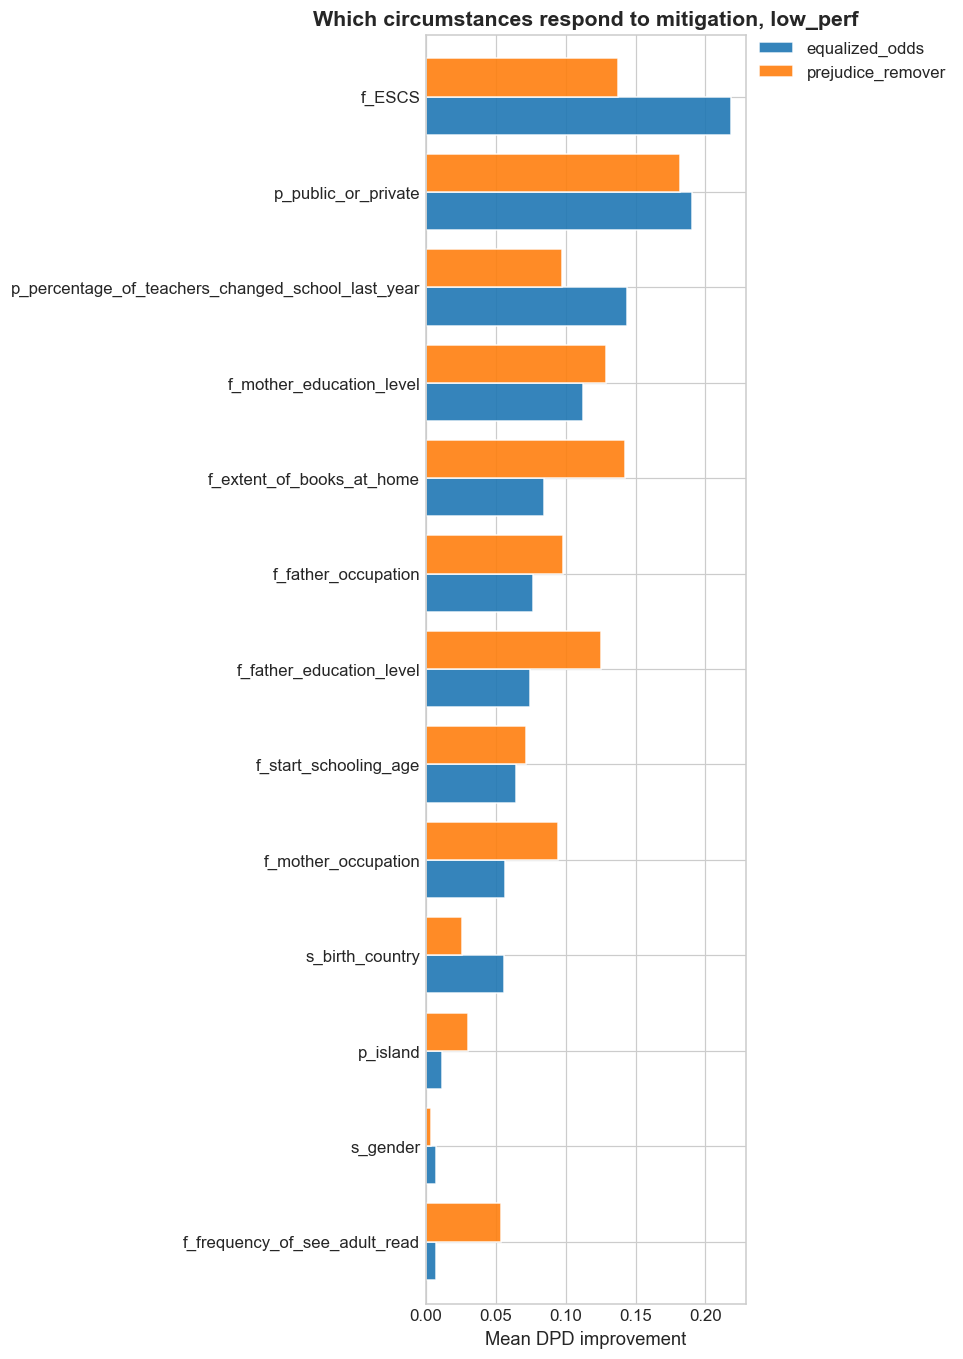

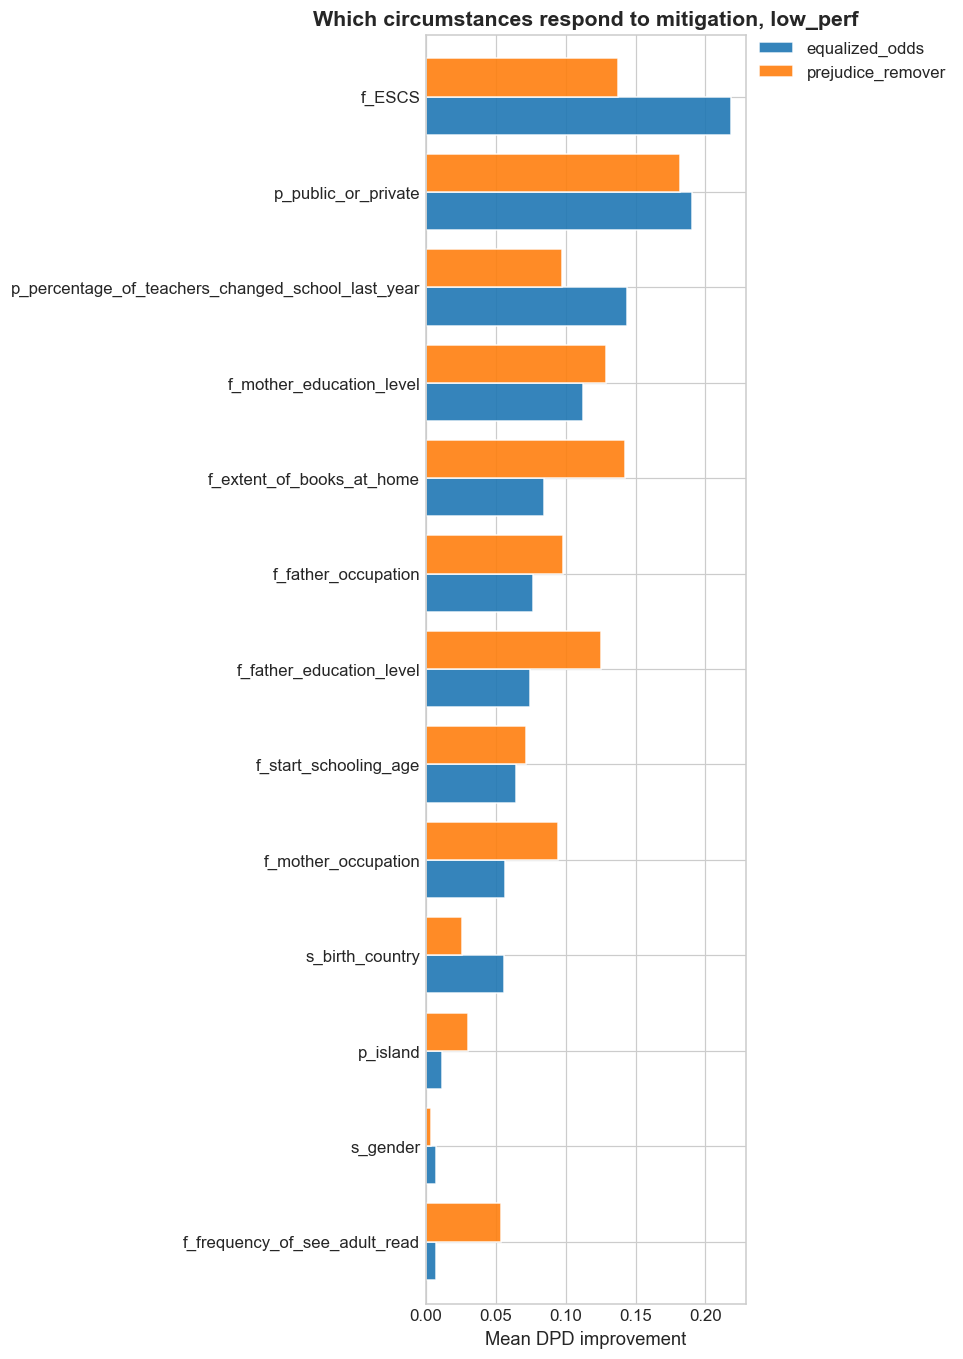

In [11]:
plot_grouped_bars(by_attribute, "Mean DPD improvement",
                  f"Which circumstances respond to mitigation, {TASK}",
                  FIGURES_DIR, "mitigation_by_attribute")

## 6. The cost in accuracy

In [12]:
cost = comparison.groupby(["technique", "source"])["balanced_accuracy"].mean().unstack("source")
unmitigated_reference_ba = (
    unmitigated.assign(source=np.where(unmitigated["method"] == BASELINE, "real", "synthetic"))
    .groupby("source")["balanced_accuracy"].mean()
)
cost.loc["none"] = unmitigated_reference_ba
print("Mean balanced accuracy, before and after mitigation:")
print(cost.round(4).to_string())

Mean balanced accuracy, before and after mitigation:
source               real  synthetic
technique                           
equalized_odds     0.6177     0.5652
prejudice_remover  0.5352     0.5378
none               0.6059     0.5702


**Observation.** The `none` row is the unmitigated starting point from G3. Comparing the
technique rows against it gives the price of the repair, separately for real and synthetic
training data.

## 7. What we take forward

- The mitigation grid for the low_perf task is saved to `mitigation_results.csv`, the before
  and after comparison to `mitigation_comparison.csv`, and the real against synthetic summary
  to `mitigation_by_source.csv`. G5 reads all three.
- Both techniques reduce the gap on the circumstance they target, at a cost in accuracy that
  differs between them.
- The comparison that matters is real against synthetic within a technique, and it has to be
  read on the residual gap as well as on the improvement, because the two training sources do
  not start from the same gap. Section 5 reports both.
- Fairness measured on a heavily unanswered circumstance rests on the students who answered,
  and mitigation of that circumstance is fitted on the same subset. Both limits are carried
  into G5 rather than resolved here.